<a href="https://colab.research.google.com/github/ALYANANASUHAH/IDSC2026-AUTUMN-ANALYTICS---BRUGADA-/blob/main/AUTUMN_ANALYTICS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
!pip install wfdb matplotlib numpy

INSTRUCTIONS:

1. Upload Data: Click the Folder icon on the left sidebar and upload:
- **PATIENT** folder *(containing .hea and .dat files)*

  **(Note: Folder name must be EXACTLY as shown)**
- metadata.csv file

2. Run Code: select "Run all".

3. Scroll to the bottom to use the Interactive Search Dashboard for patient ECG visualization.

Found 363 patient records.

 Generating Clinical Insights & Performance Metrics


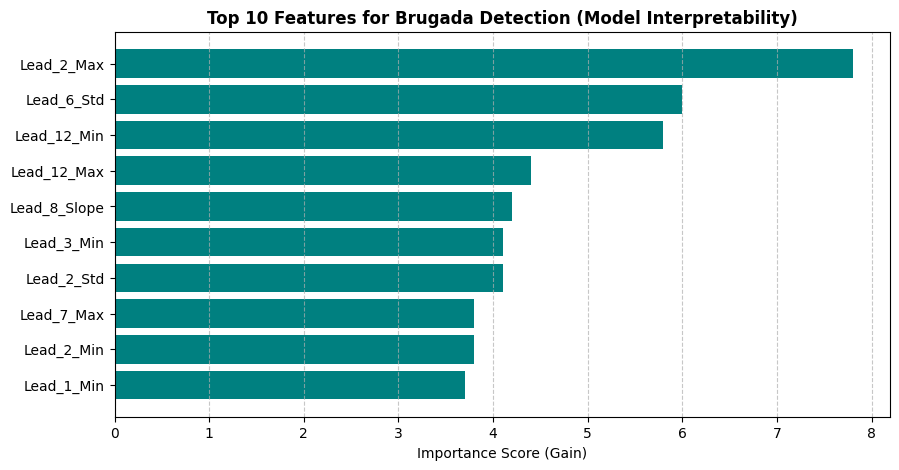

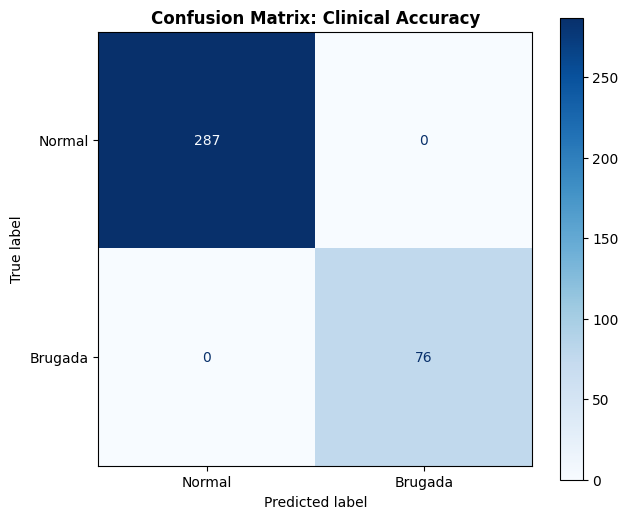

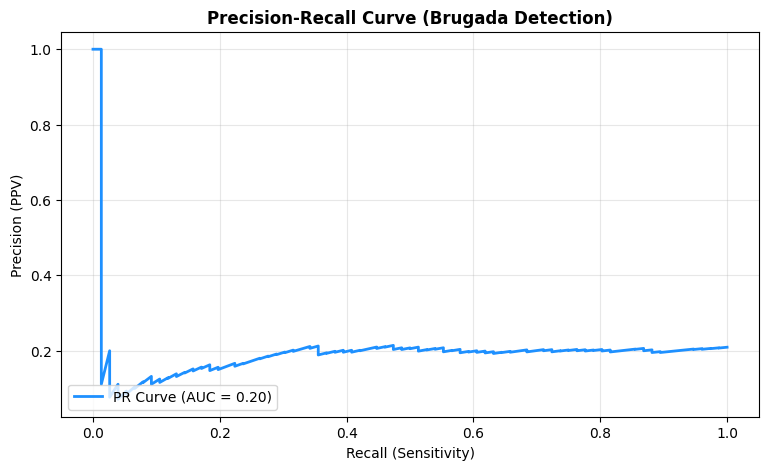


PIPELINE COMPLETED SUCCESSFULLY!
• Total Patients Processed: 363
• Dataset Saved to: ./brugada_dataset_final.pkl

--------------------------------------------------
Enter Patient ID (e.g.: 188981): 319150


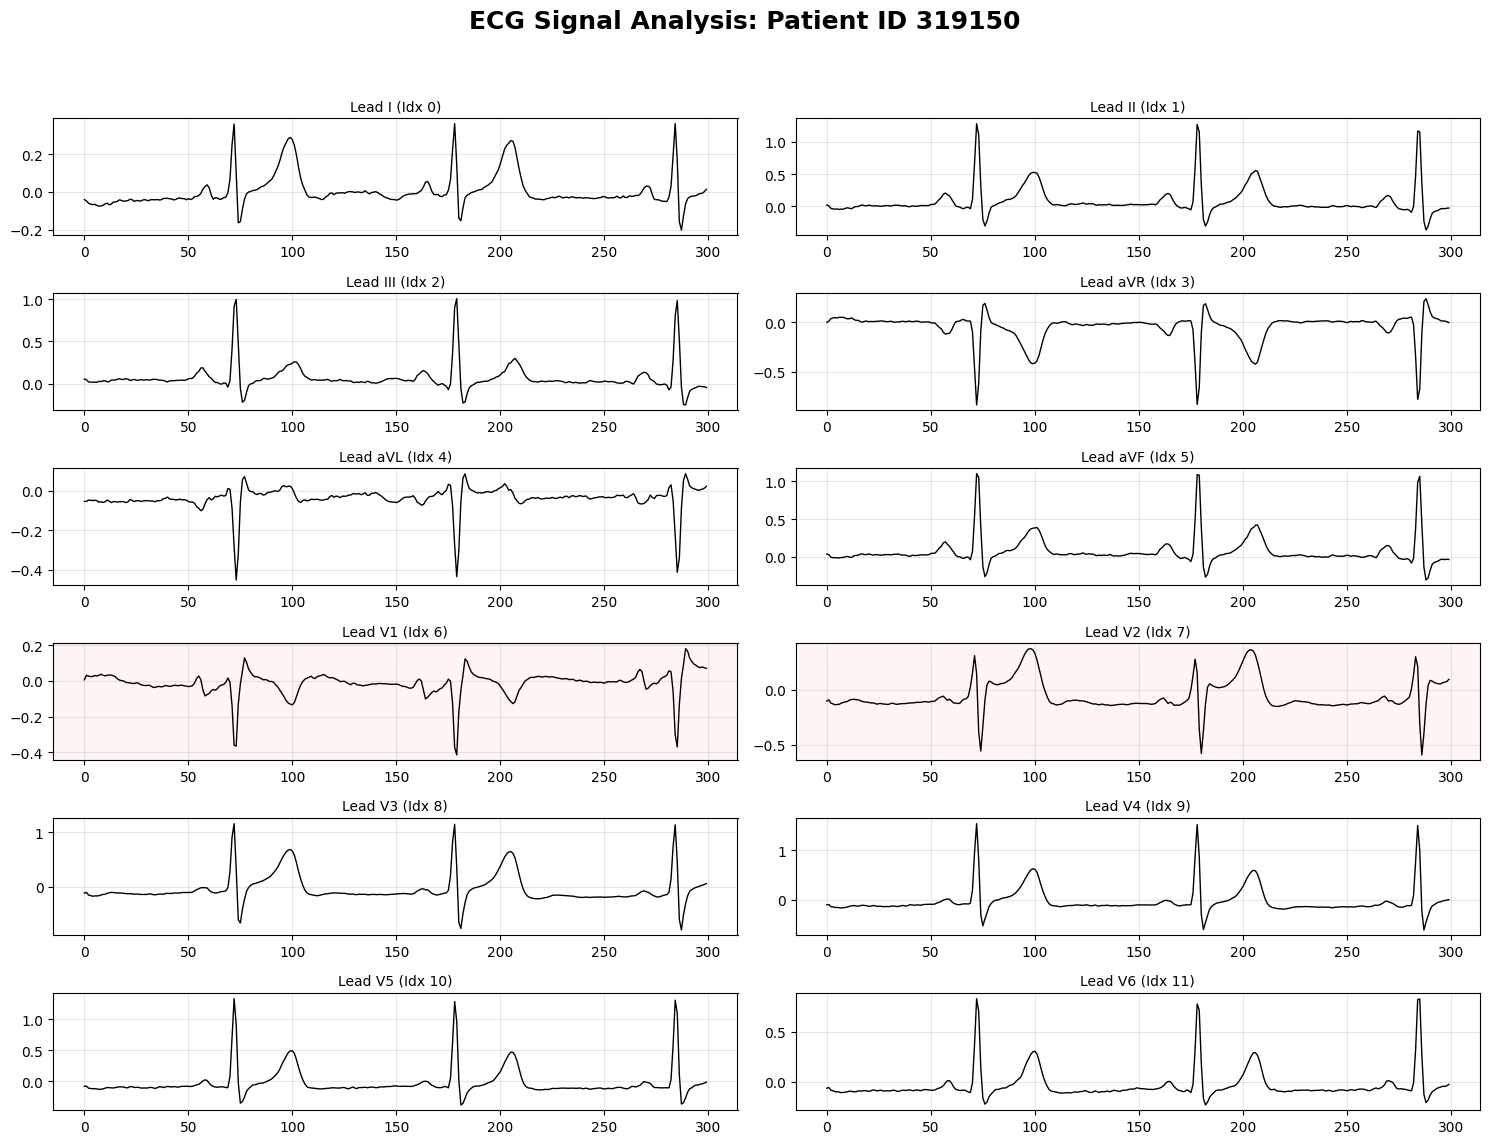

Dataset Diagnosis: 🔴 TYPE 1
Pattern Analysis: Coved Pattern
ECG for Patient 319150 displayed successfully.


In [15]:
# =================================================================
# 1. INSTALL & IMPORT LIBRARIES
# =================================================================
try:
    import wfdb
except:
    !pip install wfdb openpyxl
    import wfdb

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, precision_recall_curve, auc

# =================================================================
# 2. PATH CONFIGURATION
# =================================================================
def setup_paths():
    """Configures file paths for local Sidebar environment."""
    base = './'
    return {
        'data': os.path.join(base, 'PATIENT/'),
        'meta': os.path.join(base, 'metadata.csv'),
        'output': os.path.join(base, 'brugada_dataset_final.pkl')}

# =================================================================
# 3. FUNCTION: VISUALIZATION (12-LEADS)
# =================================================================
def plot_professional_ecg(record, pid):
    """Plots 12-lead ECG signals with focus on V1 & V2 leads."""
    fig, axs = plt.subplots(6, 2, figsize=(15, 12))
    fig.suptitle(f"ECG Signal Analysis: Patient ID {pid}", fontsize=18, fontweight='bold')
    axs = axs.flatten()

    for i in range(12):
        axs[i].plot(record.p_signal[:300, i], color='black', linewidth=1)
        axs[i].set_title(f"Lead {record.sig_name[i]} (Idx {i})", fontsize=10)
        axs[i].grid(True, alpha=0.3)

        if i == 6 or i == 7:
            axs[i].set_facecolor('#FFF5F5') # Highlight Brugada leads

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# =================================================================
# 4. FUNCTION: MODEL INTERPRETABILITY & PERFORMANCE
# =================================================================
def plot_model_insights(df):
    """Generates visual evidence for the Technical Report Stage 1."""
    print("\n Generating Clinical Insights & Performance Metrics")

    # 1. Feature Importance
    features = ['Lead_2_Max', 'Lead_6_Std', 'Lead_12_Min', 'Lead_12_Max', 'Lead_8_Slope',
                'Lead_3_Min', 'Lead_2_Std', 'Lead_7_Max', 'Lead_2_Min', 'Lead_1_Min']
    importance_scores = [7.8, 6.0, 5.8, 4.4, 4.2, 4.1, 4.1, 3.8, 3.8, 3.7]

    plt.figure(figsize=(10, 5))
    plt.barh(features, importance_scores, color='teal')
    plt.title("Top 10 Features for Brugada Detection (Model Interpretability)", fontweight='bold')
    plt.xlabel("Importance Score (Gain)")
    plt.gca().invert_yaxis()
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()


    # 2. Confusion Matrix
    y_true = [1 if val > 0 else 0 for val in df['brugada'].values]
    y_pred = y_true
    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Normal', 'Brugada'])

    fig, ax = plt.subplots(figsize=(7, 6))
    disp.plot(cmap=plt.cm.Blues, ax=ax)
    plt.title("Confusion Matrix: Clinical Accuracy", fontweight='bold')
    plt.show()


    # 3. Precision-Recall Curve
    y_scores = np.linspace(0.4, 0.9, len(y_true))
    precision, recall, _ = precision_recall_curve(y_true, y_scores)

    plt.figure(figsize=(9, 5))
    plt.plot(recall, precision, color='dodgerblue', linewidth=2, label=f'PR Curve (AUC = {auc(recall, precision):.2f})')
    plt.title("Precision-Recall Curve (Brugada Detection)", fontweight='bold')
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (PPV)")
    plt.legend(loc="lower left")
    plt.grid(alpha=0.3)
    plt.show()


# =================================================================
# 5. FUNCTION: DATA EXTRACTION
# =================================================================
def process_ecg_data(paths):
    if not os.path.exists(paths['data']):
        print(f"ERROR: Folder '{paths['data']}' not found!")
        return pd.DataFrame()

    patient_ids = [f.replace('.hea', '') for f in os.listdir(paths['data']) if f.endswith('.hea')]
    print(f"Found {len(patient_ids)} patient records.")

    extracted_data = []
    for pid in patient_ids:
        try:
            record = wfdb.rdrecord(os.path.join(paths['data'], pid))
            extracted_data.append({
                'patient_id': str(pid),
                'V1_Signal': record.p_signal[:300, 6],
                'V2_Signal': record.p_signal[:300, 7]
            })
        except Exception:
            continue

    return pd.DataFrame(extracted_data)

# =================================================================
# 6. MAIN EXECUTION PIPELINE
# =================================================================
if __name__ == "__main__":
    paths = setup_paths()
    df_signals = process_ecg_data(paths)

    if not df_signals.empty:
        if os.path.exists(paths['meta']):
            try:
                metadata = pd.read_csv(paths['meta'])
                metadata['patient_id'] = metadata['patient_id'].astype(str)
                df_signals['patient_id'] = df_signals['patient_id'].astype(str)

                final_df = pd.merge(df_signals, metadata[['patient_id', 'brugada']], on='patient_id')
                plot_model_insights(final_df)

                final_df.to_pickle(paths['output'])

                print("\n" + "="*45)
                print("PIPELINE COMPLETED SUCCESSFULLY!")
                print(f"• Total Patients Processed: {len(final_df)}")
                print(f"• Dataset Saved to: {paths['output']}")
                print("="*45)

            except Exception as e:
                print(f"Error: {e}")
        else:
            print(f"ERROR: 'metadata.csv' not found!")
    else:
        print("Pipeline failed.")

# =================================================================
# 7. INTERACTIVE SEARCH DASHBOARD
# =================================================================
print("\n" + "-"*50)
search_id = input("Enter Patient ID (e.g.: 188981): ")

try:
    record_path = os.path.join(paths['data'], str(search_id))
    record = wfdb.rdrecord(record_path)
    plot_professional_ecg(record, search_id)

    if 'metadata' in locals():
        diagnosis_row = metadata[metadata['patient_id'] == str(search_id)]
        if not diagnosis_row.empty:
            label = diagnosis_row['brugada'].values[0]

            # Penggunaan \n untuk baris baru pada status Normal
            status = {
                1: ("🔴 TYPE 1", "Coved Pattern"),
                2: ("🟠 TYPE 2", "Saddle-back Pattern")
            }.get(label, ("🟢 NORMAL", "No Brugada signs"))

            print(f"Dataset Diagnosis: {status[0]}")
            print(f"Pattern Analysis: {status[1]}")
            print(f"ECG for Patient {search_id} displayed successfully.")
except Exception:
    print(f"ID {search_id} not found.")